In [2]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc

In [99]:
res_dressed = "/2025-02-19/2025-02-19T172713_52053dfa-cw_sparameter"
# punchout =  "/2024-07-12/2024-07-12T163402_1c9bb492-cw_punchout"  # R.T.: -30dB, vna output: -20 ~ 20dB

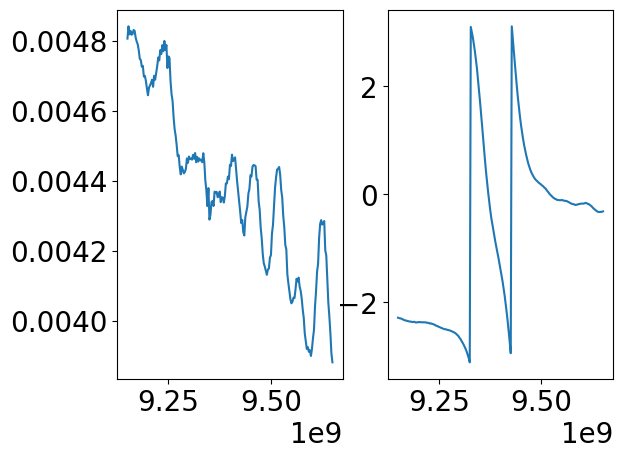

In [100]:
header = "D:/K_sunada/result/CDK174_test/"
dd_d = datadict_from_hdf5(header + res_dressed +"/data")

freq_d = dd_d['frequency']['values']
s11_d = dd_d['s21']['values']
# freq_b = dd_b['frequency']['values']
# s11_b = dd_b['s21']['values']

fig,ax = plt.subplots(1,2)
ax[0].plot(freq_d,np.abs(s11_d))
ax[1].plot(freq_d,np.angle(s11_d))

double pole

In [110]:
def S11_dpr_model(freq, fr, ff, kf_e, kf_i, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-ff)+(kf_e-kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    denom = (1j*(freq-ff)-(kf_e+kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*(freq-freq[0])))).conj()
    return model

par_ini = {'fr': 9.42e9,  'ff': 9.36e9,    'kf_e': 140e6,   'kf_i': 0.e6,  'g': 60e6, 'gamma': 0.e6,
           'a0': -0.016,  'a1': 6.4832e-11	,        'Poff': 42473.7558,   'ed': -8.7329e-10}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed': True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
    
result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')
# result_b = model.fit(freq=freq_b, data=s11_b, params=params, method='leastsq')

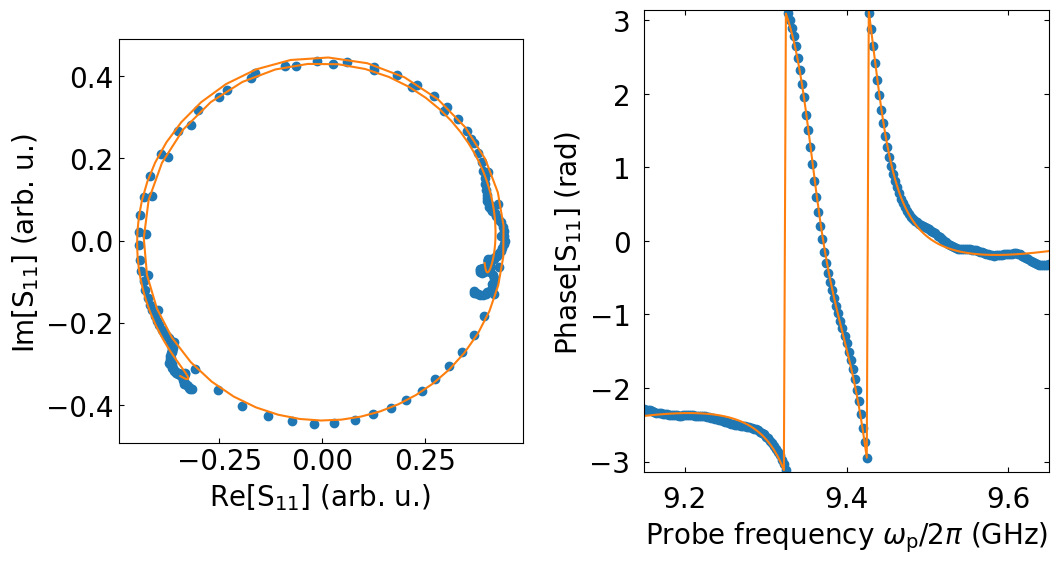

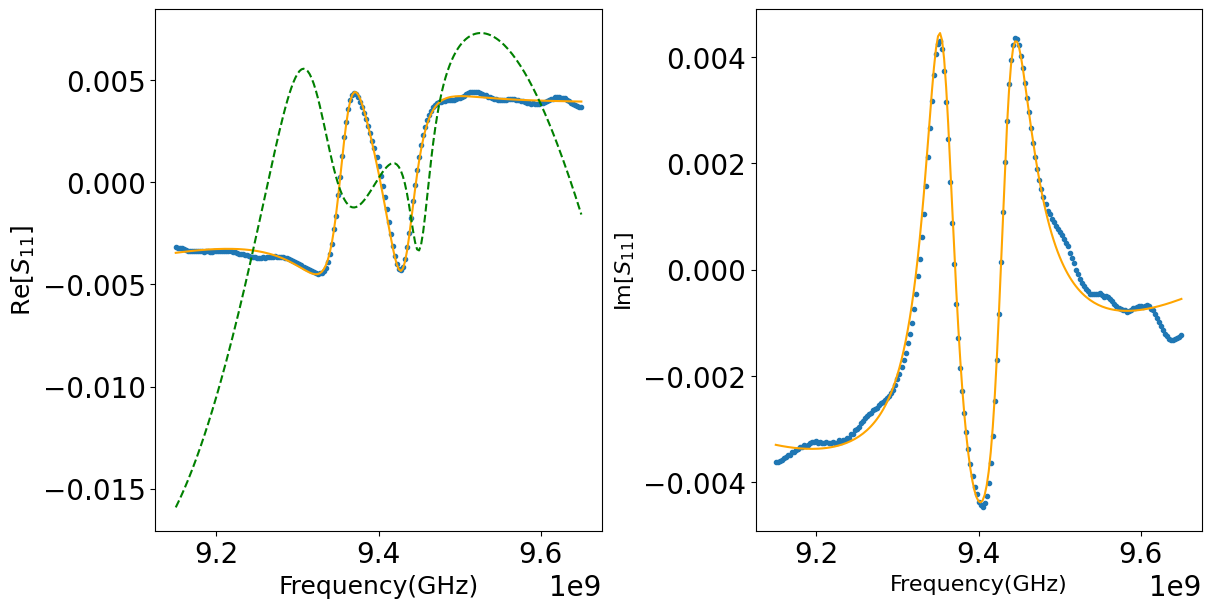

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].plot(np.real(s11_d)*1e2,np.imag(s11_d)*1e2, ls='', marker='o')
ax[0].plot(np.real(result_d.best_fit)*1e2,np.imag(result_d.best_fit)*1e2)
# ax[0].plot(np.real(result_d.init_fit)*1e2,np.imag(result_d.init_fit)*1e2, color='green', ls='--', )
# plt.xticks([-0.6, -0.4, 0.2, 0, 0.2, 0.4, 0.6])

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(9.15, 9.65)
ax[1].set_ylim(-np.pi, np.pi)
# ax[1].set_aspect("equal", adjustable="box")
ax[1].plot(freq_d*1e-9,np.angle(s11_d), ls='', marker='o')
ax[1].plot(freq_d*1e-9,np.angle(result_d.best_fit))
# ax[1].plot(freq_d*1e-9,np.angle(result_d.init_fit), color='green', ls='--', )

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=18)
ax[0].set_ylabel('Re[$S_{11}]$', fontsize=18)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Im[$S_{11}]$', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq_d,np.real(s11_d), ls='', marker='.')
ax[0].plot(freq_d,np.real(result_d.best_fit), color='orange')
ax[0].plot(freq_d,np.real(result_d.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq_d,np.imag(s11_d), ls='', marker='.')
ax[1].plot(freq_d,np.imag(result_d.best_fit), color='orange')
result_d


punchout

In [13]:
dd = datadict_from_hdf5(header + punchout +"/data")
dd

NameError: name 'punchout' is not defined

In [ ]:
dd = datadict_from_hdf5(header + punchout +"/data")
x = np.unique(dd['power']['values'])
y = np.unique(dd['frequency']['values'])
z = dd['s11']['values']

C:\Users\qipe\AppData\Local\Temp\ipykernel_8428\1458322726.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


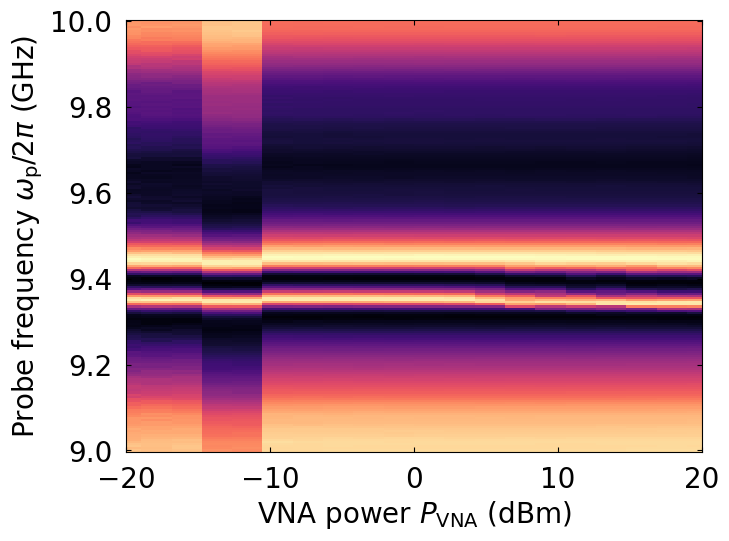

In [ ]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("VNA power $P_{\mathrm{VNA}}$ (dBm)")
ax.set_ylabel("Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)")
ax.set_xlim(-20, 20)
# ax.set_ylim(9, 10.)

maingraph = ax.pcolormesh(x,y*1e-9, np.real(z).reshape(20, 201).T, vmin=min(np.unique(np.real(z))), vmax=max(np.unique(np.real(z))), cmap=cm, shading='auto')


plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on')
# plt.savefig('punchout.png', bbox_inches='tight')
plt.show()


# frequency optimization

In [1]:
import sklearn
from sklearn.decomposition import PCA

In [2]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [3]:
def Lorentzian(freq, amp, const, center, k):
    return const + amp*k**2/((freq-center)**2 + k**2)

In [4]:
data = "/2024-07-24/2024-07-24T160833_8a16ac4e-26_freq_optimize"
dd = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq = dd['frequency']['values']
s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_e = dd['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_eg_div = s11_e / s11_g

I = s11_eg.real
Q = s11_eg.imag
plt.plot(freq, np.abs(s11_eg))
PCAge = PCA_transform(I, Q)

NameError: name 'datadict_from_hdf5' is not defined

S11^e-S11^g

In [100]:
model = lmfit.Model(Lorentzian)

par_ini = {'amp': 125,'const':1,'center':10.378e9,'k':0.008e9}
par_min = {'amp': 0,'const':0,'center':0,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name], min = par_min[name], max = par_max[name], vary = par_vary[name])

result = model.fit(data = np.abs(s11_eg), params = params, freq = freq)
result

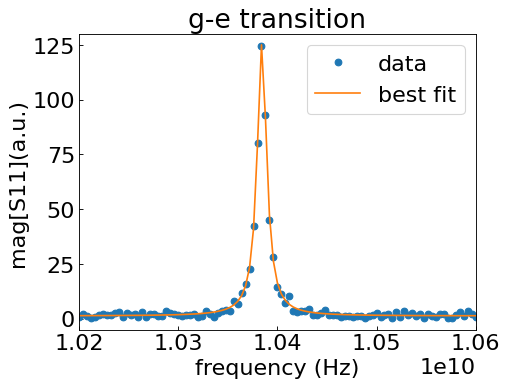

In [102]:
fig, ax = plt.subplots(dpi=80)

plt.title("S11^e-S11^g")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.xlim(10.2e9, 10.6e9)
plt.ylim(-5, 130)
plt.xlabel("frequency (Hz)")
plt.ylabel("mag[S11](a.u.)")
plt.show()

S11^e/S11^g

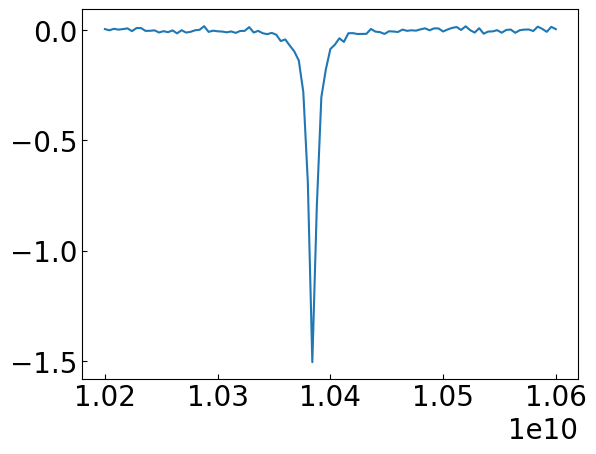

In [103]:
I = s11_eg_div.real
Q = s11_eg_div.imag
plt.plot(freq, np.angle(s11_eg_div))

In [ ]:
def s11_ge_dp(f, f_r, f_f, k_ex, k_in, chi, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-(f_r+chi)) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-(f_r+chi))-gamma/2) + g**2)
    return (s11_g/s11_e).conj()
def guess_params_dp(data,x):
    par_ini = {"f_r":10.2664, "f_f":10.1739, "k_ex":0.20255, "k_in":0.002, "chi":-5e-3, "g":0.08182, "gamma":0, "phi":0,}
    par_max = {"f_r":11, "f_f":11, "k_ex":0.8, "k_in":100e-3, "chi":0, "g":1, "gamma":.3, "phi":2 * np.pi,}
    par_min = {"f_r":10, "f_f":10, "k_ex":0, "k_in":0e-3, "chi":-50e-3, "g":0, "gamma":0, "phi":-2*np.pi,}
    par_vary = {"f_r":1, "f_f":0, "k_ex":1, "k_in":0, "chi":True, "g":1, "gamma":0, "phi":1}
    return par_ini,par_max,par_min,par_vary
def probe_resonator_fit_dp(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # 初期値
            min=par_min[name],  # 下限値
            max=par_max[name],  # 上限値
            vary=par_vary[name] # パラメータを動かすかどうか
        )
    result=model.fit(data, f

Chi fitting

- one pole

In [120]:
par_ini = {'fc':10.386e9, 'ke':11e6, 'ki':1e6, 'a0':-195, 'a1':-7.0880e-08, 'Poff':-42460, 'ed':8.1773e-10}
par_min = {'fc':0, 'ke':0, 'ki':0, 'a0':-np.inf, 'a1':-np.inf, 'Poff':-np.inf, 'ed':-np.inf}
par_max = {'fc':np.inf, 'ke':np.inf, 'ki':np.inf, 'a0':np.inf, 'a1':np.inf, 'Poff':np.inf, 'ed':np.inf}
par_var = {'fc':True, 'ke':True, 'ki':True, 'a0':True, 'a1':True, 'Poff':True, 'ed':True}
model=lmfit.Model(resonator)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])
# result_d = model.fit(freq=freq_d, data=s11_d, params=params, method='leastsq')

- double pole

In [ ]:
par_ini = {'fr': 9.35e9,  'ff': 9.4e9,    'kf_e': 108e6,   'kf_i': 0.e6,  'g': 14e6, 'gamma': 0.e6,
           'a0': 18,  'a1': 3.5e-7	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed':  True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

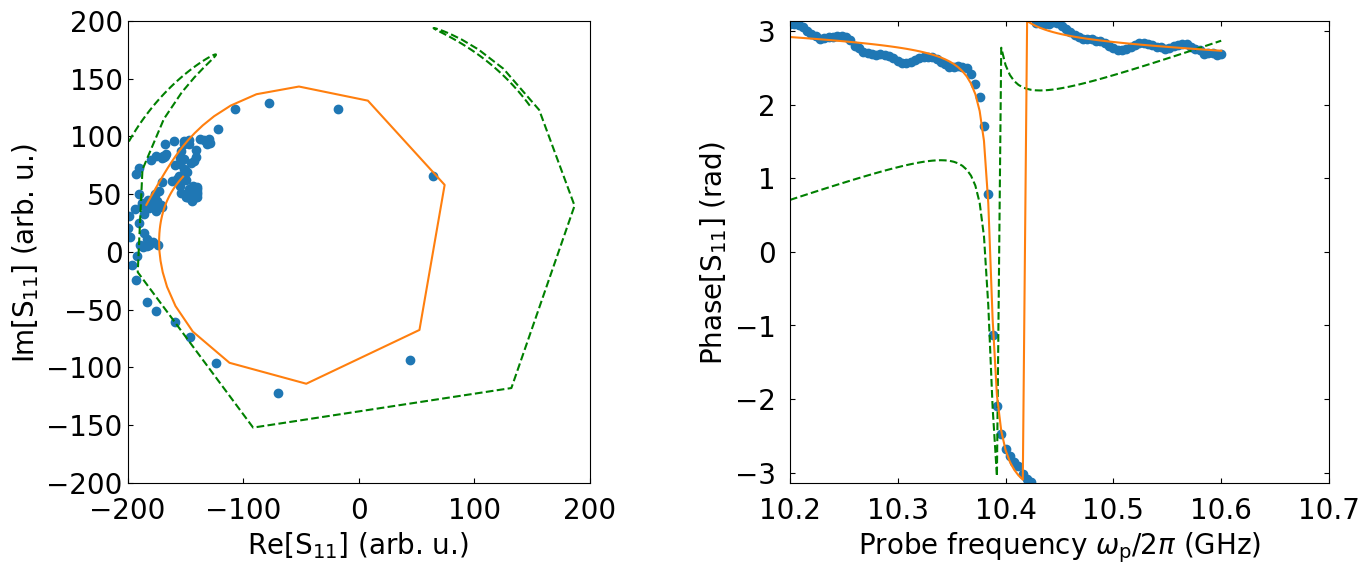

In [121]:
res = model.fit(data = s11_g, params = params, freq = freq)

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-200, 200)
ax[0].set_ylim(-200, 200)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(10.2, 10.7)
ax[1].set_ylim(-np.pi, np.pi)


ax[0].plot(np.real(s11_g),np.imag(s11_g) , ls='', marker='o')
ax[0].plot(np.real(res.init_fit), np.imag(res.init_fit), '--', label='initial fit', color='green')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(freq*1e-9, np.angle(s11_g),  ls='', marker='o')
ax[1].plot(freq*1e-9, np.angle(res.init_fit), '--', label='initial fit', color='green')
ax[1].plot(freq*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_g.png', bbox_inches='tight')
plt.show()
res

In [ ]:
par_ini = {'fr': 9.38e9,  'ff': 9.4e9,    'kf_e': 108e6,   'kf_i': 0.e6,  'g': 45e6, 'gamma': 0.e6,
           'a0': 50,  'a1': 3.5e-7	,        'Poff': -19575,   'ed': 6e-12}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': -np.inf,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': False,    'g': True, 'gamma': False,
           'a0': True, 'a1': True,    'Poff': True,  'ed':  True}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
for name in list(par_min):
    params[name].set(min=par_min[name])  
for name in list(par_max):
    params[name].set(max=par_max[name]) 
for name in list(par_var):
    params[name].set(vary=par_var[name])

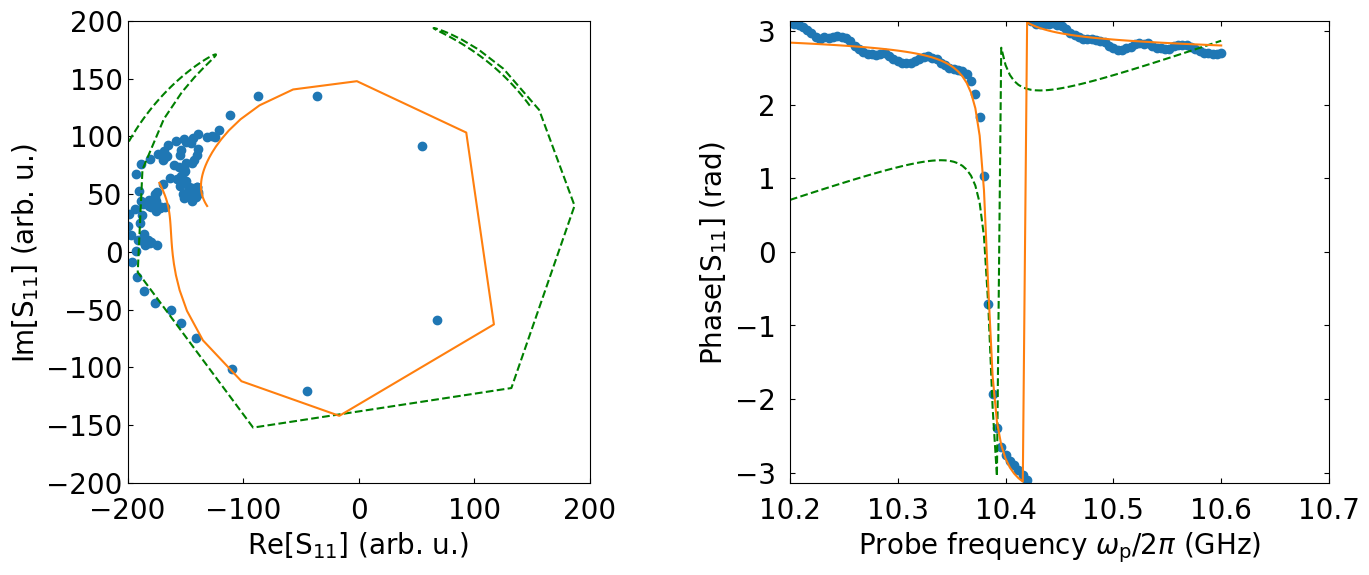

In [122]:
res = model.fit(data = s11_e, params = params, freq = freq, method='nelder')

fig, ax = plt.subplots(1, 2, figsize=(16,6))#,constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.subplots_adjust(wspace=0.3)
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlabel('Re[S$_{11}$] (arb. u.) ')
ax[0].set_ylabel('Im[S$_{11}$] (arb. u.) ')
ax[0].tick_params(axis="x", direction="in")
ax[0].tick_params(axis="y", direction="in")
ax[0].set_xlim(-200, 200)
ax[0].set_ylim(-200, 200)
ax[0].get_xaxis().set_tick_params(pad=10)

ax[1].set_xlabel('Probe frequency $\omega_\mathrm{p}/2\pi$ (GHz)')
ax[1].set_ylabel('Phase[S$_{11}$] (rad) ')
ax[1].tick_params(axis="x", direction="in")
ax[1].tick_params(axis="y", direction="in")
ax[1].set_xlim(10.2, 10.7)
ax[1].set_ylim(-np.pi, np.pi)

ax[0].plot(np.real(s11_e), np.imag(s11_e),  ls='', marker='o')
# ax[0].plot(x, np.real(s11_e),'.', color='k')
ax[0].plot(np.real(res.init_fit), np.imag(res.init_fit),'--', label='initial fit', color='green')
# ax[0].plot(np.real(res.best_fit),np.imag(res.best_fit), '-', label='best fit', color='red')
ax[0].plot(np.real(res.best_fit), np.imag(res.best_fit))
ax[1].plot(freq*1e-9, np.angle(s11_e),  ls='', marker='o')
ax[1].plot(freq*1e-9, np.angle(res.init_fit), '--', label='initial fit', color='green')
ax[1].plot(freq*1e-9, np.angle(res.best_fit))
# plt.savefig('chi_e.png', bbox_inches='tight')
plt.show()
res

In [123]:
(10.383-10.387)/2

-0.002000000000000668

In [ ]:
f_hg = 9.3951e9
f_lg = 9.3766e9
f_he = 9.3946e9
f_le = 9.3704e9

chi_l = (f_le - f_lg)/2
chi_h = (f_he - f_hg)/2 
chi = chi_l
chi

-3100000.0